In [1]:
'''
    Code to visualize differences in calculated ORs across two contexts using Pain et al. (2022) and logistic regression
'''

import pandas as pd
import numpy as np
import random
import time

from options.options import Options
import util.util as util
import util.pre_process as pre

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
import numpy as np

phen_labels = ['AFIB', 'CAD', 'T2D', 'HCA', 'AST', 'OB', 'MDD']

opt = Options()
opt.initialize()

In [2]:
gt_dict = {}

for phen in phen_labels:
    gt_dict[phen] = np.load(f'results/{phen}/gt_comparisons.npy', allow_pickle=True).item()

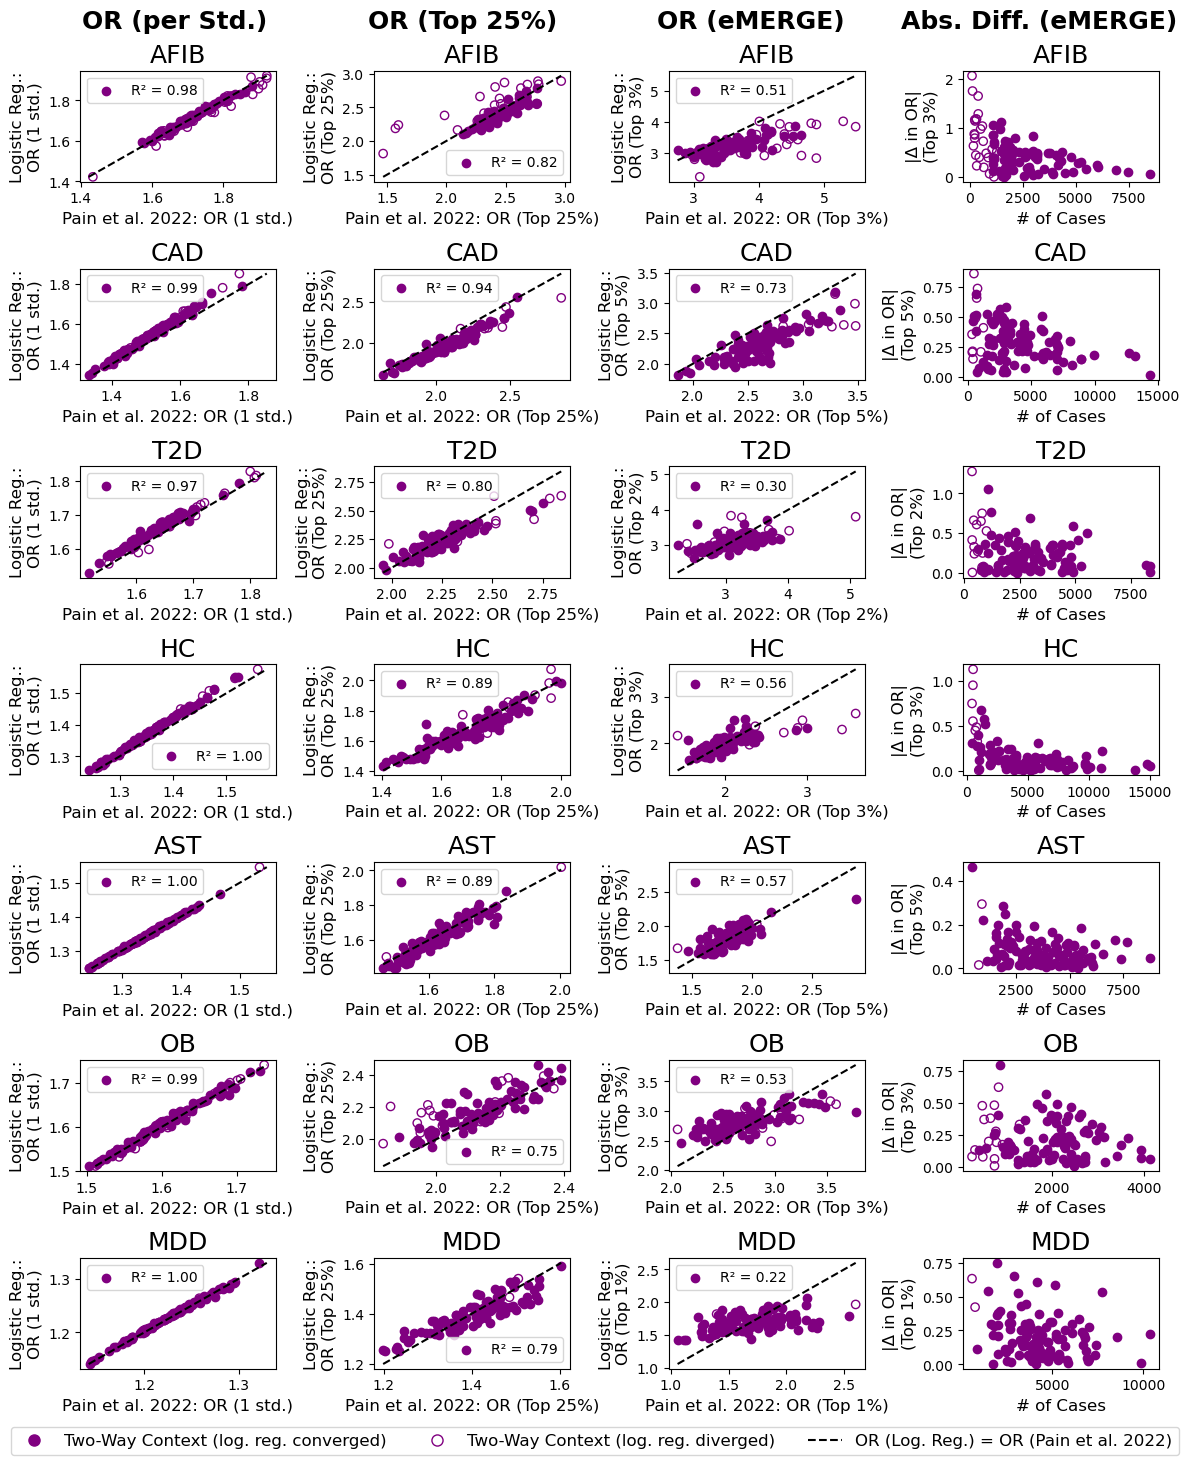

In [3]:
from matplotlib.lines import Line2D
fig, axs = plt.subplots(len(phen_labels), 4, figsize=(12, len(phen_labels) * 2))

column_titles = ['OR (per Std.)', 'OR (Top 25%)', 'OR (eMERGE)', 'Abs. Diff. (eMERGE)']

for j, title in enumerate(column_titles):
    fig.text(0.15 + j * 0.24, 1.0, title, fontsize=18, fontweight='bold', ha='center')

for i, phen in enumerate(phen_labels):
    phen_title = opt.phen_params[phen]['title']
    
    top_or_gt = util.extract_2way_interactions(gt_dict[phen]['top_or_log'])
    top_or_converged = util.extract_2way_interactions(gt_dict[phen]['top_or_log_converged']) > 0
    top_or = util.extract_2way_interactions(gt_dict[phen]['top_or'])
    
    top_quant_or_gt = util.extract_2way_interactions(gt_dict[phen]['top_quant_or_log'])
    top_quant_or_converged = util.extract_2way_interactions(gt_dict[phen]['top_quant_or_log_converged']) > 0
    top_quant_or = util.extract_2way_interactions(gt_dict[phen]['top_quant_or'])
    
    or_gt = util.extract_2way_interactions(gt_dict[phen]['or_log'])
    or_converged = util.extract_2way_interactions(gt_dict[phen]['or_log_converged']) > 0
    or_ = util.extract_2way_interactions(gt_dict[phen]['or'])
    
    n = util.extract_2way_interactions(gt_dict[phen]['n']) * util.extract_2way_interactions(gt_dict[phen]['prev'])

    r2 = np.corrcoef(or_[or_converged], or_gt[or_converged])[0, 1] ** 2
    axs[i, 0].scatter(or_[or_converged], or_gt[or_converged], color='purple', label=f'R² = {r2:.2f}')
    axs[i, 0].legend(loc='best')
    axs[i, 0].scatter(or_[~or_converged], or_gt[~or_converged], color='purple', marker='o', facecolors='none')
    axs[i, 0].plot([min(or_gt), max(or_gt)], [min(or_gt), max(or_gt)], 'k--')
    axs[i, 0].set_title(f'{phen_title}', fontsize=18)
    axs[i, 0].set_xlabel('Pain et al. 2022: OR (1 std.)', fontsize=12)
    axs[i, 0].set_ylabel('Logistic Reg.:\nOR (1 std.)', fontsize=12)

    r2 = np.corrcoef(top_quant_or_gt[top_quant_or_converged], top_quant_or[top_quant_or_converged])[0, 1] ** 2
    axs[i, 1].scatter(top_quant_or_gt[top_quant_or_converged], top_quant_or[top_quant_or_converged], color='purple', label=f'R² = {r2:.2f}')
    axs[i, 1].legend(loc='best')
    axs[i, 1].scatter(top_quant_or_gt[~top_quant_or_converged], top_quant_or[~top_quant_or_converged], color='purple', marker='o', facecolors='none')
    axs[i, 1].plot([min(top_quant_or_gt), max(top_quant_or_gt)], [min(top_quant_or_gt), max(top_quant_or_gt)], 'k--')
    axs[i, 1].set_xlabel("Pain et al. 2022: OR (Top 25%)", fontsize=12)
    axs[i, 1].set_ylabel("Logistic Reg.:\nOR (Top 25%)", fontsize=12)
    axs[i, 1].set_title(f'{phen_title}', fontsize=18)

    r2 = np.corrcoef(top_or_gt[top_or_converged], top_or[top_or_converged])[0, 1] ** 2
    axs[i, 2].scatter(top_or_gt[top_or_converged], top_or[top_or_converged], color='purple', label=f'R² = {r2:.2f}')
    axs[i, 2].legend(loc='best')
    axs[i, 2].scatter(top_or_gt[~top_or_converged], top_or[~top_or_converged], color='purple', marker='o', facecolors='none')
    axs[i, 2].plot([min(top_or_gt), max(top_or_gt)], [min(top_or_gt), max(top_or_gt)], 'k--')
    axs[i, 2].set_xlabel(f"Pain et al. 2022: OR (Top {int(100 * opt.phen_params[phen]['emerge_cut'])}%)", fontsize=12)
    axs[i, 2].set_ylabel(f"Logistic Reg.:\nOR (Top {int(100 * opt.phen_params[phen]['emerge_cut'])}%)", fontsize=12)
    axs[i, 2].set_title(f'{phen_title}', fontsize=18)

    axs[i, 3].scatter(n[top_or_converged], abs(np.array(top_or_gt[top_or_converged]) - np.array(top_or[top_or_converged])), color='purple')
    axs[i, 3].scatter(n[~top_or_converged], abs(np.array(top_or_gt[~top_or_converged]) - np.array(top_or[~top_or_converged])), color='purple', marker='o', facecolors='none')
    axs[i, 3].set_xlabel("# of Cases", fontsize=12)
    axs[i, 3].set_ylabel(f"|Δ in OR|\n(Top {int(100 * opt.phen_params[phen]['emerge_cut'])}%)", fontsize=12)
    axs[i, 3].set_title(f'{phen_title}', fontsize=18)

custom_lines = [
    Line2D([], [], marker='o', linestyle='None', color='purple', markerfacecolor='purple', markersize=8, label='Two-Way Context (log. reg. converged)'),
    Line2D([], [], marker='o', linestyle='None', color='purple', markerfacecolor='white', markersize=8, label='Two-Way Context (log. reg. diverged)'),
    Line2D([], [], color='black', linestyle='--', label='OR (Log. Reg.) = OR (Pain et al. 2022)')
]
fig.legend(handles=custom_lines, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.025))

plt.tight_layout()
plt.savefig('results/error_check.png', bbox_inches='tight')
plt.show()